# Round Results Analysis

Loads the `.json` (results) and `.log` (execution) files from a Prosperity submission and produces 7 diagnostic charts.

**Change `LOG_DIR` to point at any submission folder — everything else auto-adapts.**

---
### File guide
| File | Contents |
|---|---|
| `*.json` | `profit`, `activitiesLog` (order-book snapshots), `graphLog` (PnL curve), `positions` (final holdings) |
| `*.log`  | `submissionId`, same `activitiesLog`, `logs` (sandbox/lambda per tick), `tradeHistory` (every filled trade) |

In [74]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
LOG_DIR = "../logs/233117"   # ← change to your submission folder

# Static fair values (from trader.py).  Dynamic products (e.g. rolling-window)
# are skipped in sections that require a fixed reference price.
FAIR_VALUES = {
    "ASH_COATED_OSMIUM": 10000,
}

POSITION_LIMIT = 80   # absolute limit (same for both products this round)
# ───────────────────────────────────────────────────────────────────────────

In [75]:
import os
OUTPUT_DIR = os.path.join(os.path.dirname(LOG_DIR), "..", "notebooks", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [76]:
import json
import glob
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ── Load files ─────────────────────────────────────────────────────────────
json_path = glob.glob(f"{LOG_DIR}/*.json")[0]
log_path  = glob.glob(f"{LOG_DIR}/*.log")[0]

with open(json_path) as f:
    results = json.load(f)
with open(log_path) as f:
    execution = json.load(f)

# ── activitiesLog ──────────────────────────────────────────────────────────
acts = pd.read_csv(io.StringIO(results["activitiesLog"]), sep=";",
                   dtype={"day": int, "timestamp": int})
# Compute a global tick index so plots read left-to-right across days
max_ts = acts["timestamp"].max()
acts["global_ts"] = acts["day"] * (max_ts + 100) + acts["timestamp"]

# ── graphLog (PnL curve) ────────────────────────────────────────────────────
pnl_curve = pd.read_csv(io.StringIO(results["graphLog"]), sep=";")

# ── tradeHistory ────────────────────────────────────────────────────────────
trades = pd.DataFrame(execution["tradeHistory"])
if len(trades) > 0:
    trades["side"] = trades.apply(
        lambda r: "BUY"  if r["buyer"]  == "SUBMISSION" else
                  "SELL" if r["seller"] == "SUBMISSION" else "OTHER",
        axis=1
    )
    trades["signed_qty"] = trades.apply(
        lambda r: r["quantity"] if r["side"] == "BUY" else -r["quantity"],
        axis=1
    )
else:
    trades = pd.DataFrame(columns=["timestamp","buyer","seller","symbol","currency","price","quantity","side","signed_qty"])

# ── Final positions ─────────────────────────────────────────────────────────
final_pos = {p["symbol"]: p["quantity"] for p in results.get("positions", [])}

products = sorted(acts["product"].unique())

print(f"Submission : {execution['submissionId']}")
print(f"Round      : {results['round']}  |  Status: {results['status']}")
print(f"Total PnL  : {results.get('profit', 0) or 0:.4f} XIRECS")
print(f"Trades     : {len(trades)}")
print(f"Products   : {products}")
print(f"Final pos  : {final_pos}")

with open(f"{OUTPUT_DIR}/results_00_run_info.txt", "w") as f:
    f.write(f"Submission : {execution['submissionId']}\n")
    f.write(f"Round      : {results['round']}  |  Status: {results['status']}\n")
    f.write(f"Total PnL  : {results.get('profit', 0) or 0:.4f} XIRECS\n")
    f.write(f"Trades     : {len(trades)}\n")
    f.write(f"Products   : {products}\n")
    f.write(f"Final pos  : {final_pos}\n")

Submission : 4f562dc3-f3f5-45cd-91ad-5e0927248696
Round      : 1  |  Status: FINISHED
Total PnL  : 9817.9375 XIRECS
Trades     : 115
Products   : ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Final pos  : {'ASH_COATED_OSMIUM': -14, 'INTARIAN_PEPPER_ROOT': 80, 'XIRECS': -818136}


---
## 1. Cumulative PnL Curve
Shows *when* profit was earned.  A steep early rise means the algo captures the first mispricing quickly; a flat plateau means it stopped trading (likely position-constrained).

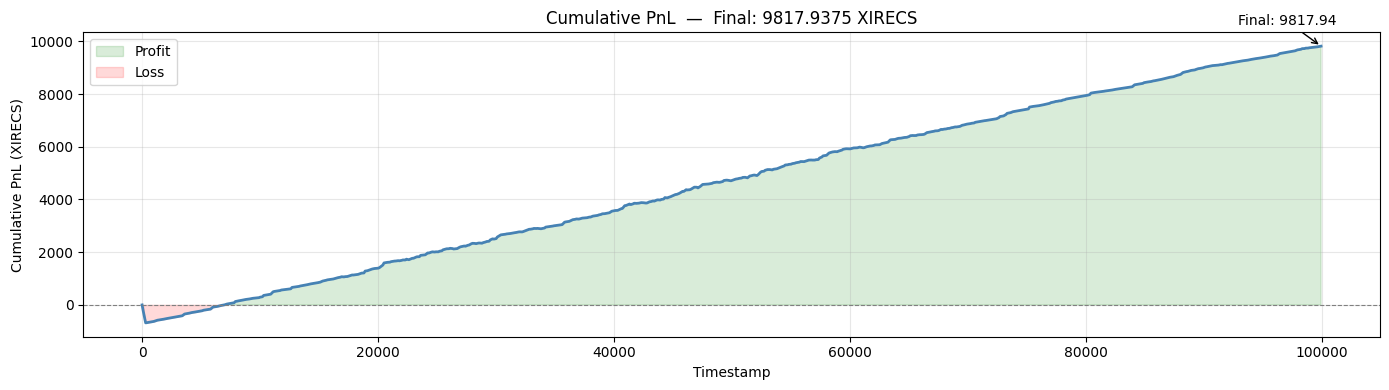

In [77]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(pnl_curve["timestamp"], pnl_curve["value"], linewidth=2, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.fill_between(pnl_curve["timestamp"], pnl_curve["value"], 0,
                where=pnl_curve["value"] >= 0, alpha=0.15, color="green", label="Profit")
ax.fill_between(pnl_curve["timestamp"], pnl_curve["value"], 0,
                where=pnl_curve["value"] < 0, alpha=0.15, color="red",   label="Loss")

final_val = pnl_curve["value"].iloc[-1]
ax.annotate(f"Final: {final_val:.2f}",
            xy=(pnl_curve["timestamp"].iloc[-1], final_val),
            xytext=(-60, 15), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)

total_profit = results.get('profit', 0) or 0
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative PnL (XIRECS)")
ax.set_title(f"Cumulative PnL  —  Final: {total_profit:.4f} XIRECS")
ax.legend()
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_01_cumulative_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Mid Price & Spread Per Product
**Top panel**: mid price (blue) with per-product PnL on the right axis (orange).  
**Bottom panel**: bid-ask spread over time.  A tight, stable spread means consistent market-making conditions.

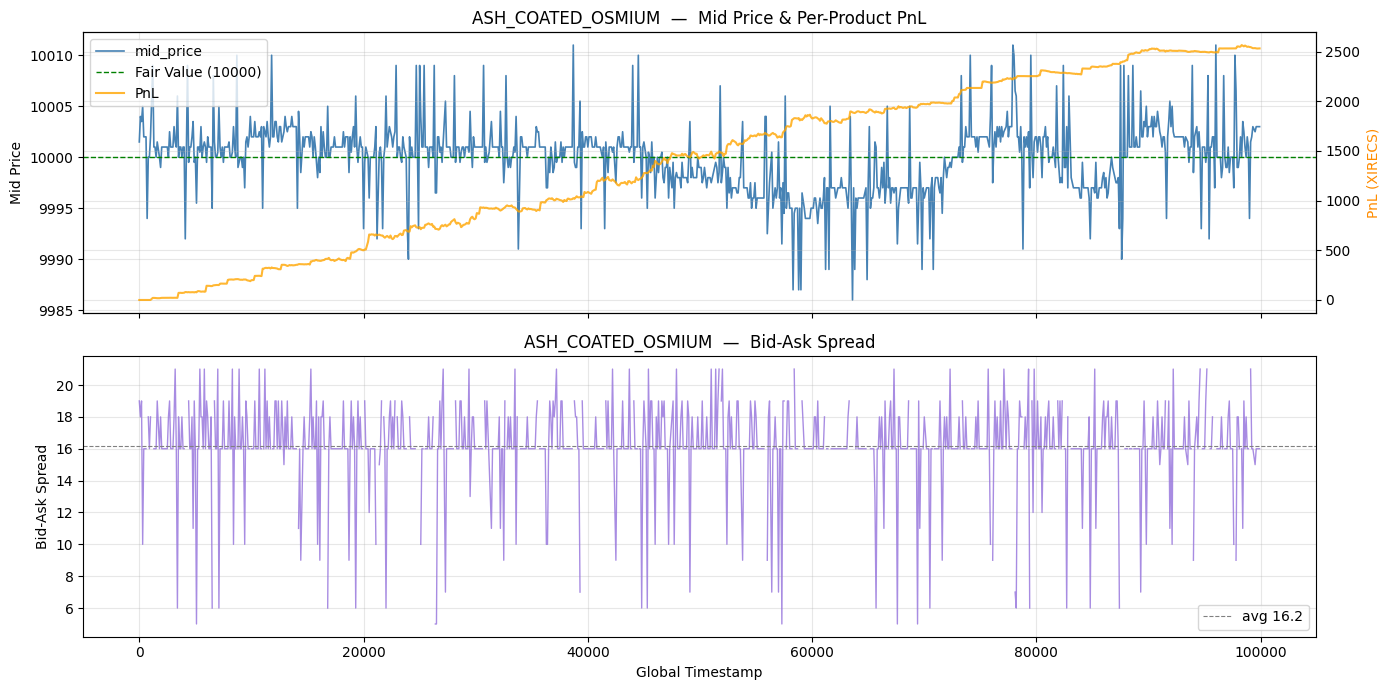

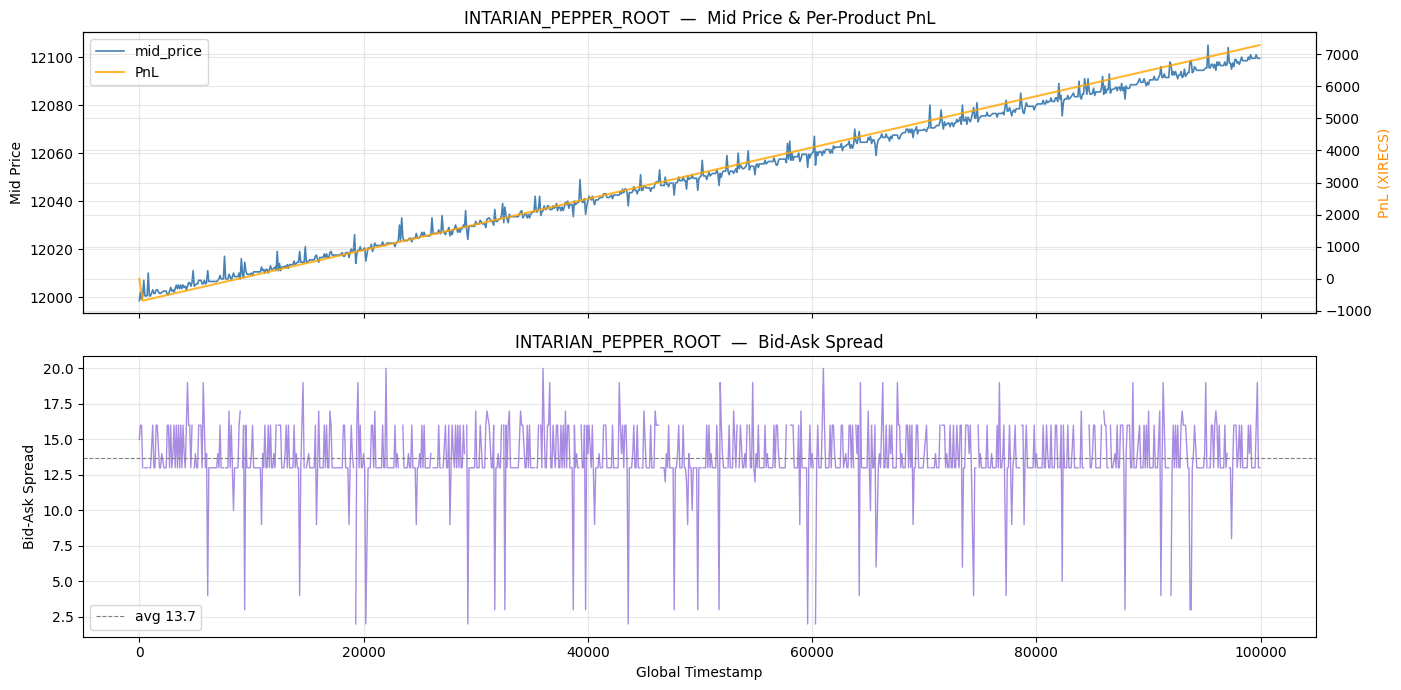

In [78]:
for product in products:
    p = acts[acts["product"] == product].copy()
    p["spread"] = p["ask_price_1"] - p["bid_price_1"]
    p["mid_price"] = p["mid_price"].replace(0, np.nan).ffill()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # ── Top: mid price + PnL ────────────────────────────────────────────────
    ax1.plot(p["global_ts"], p["mid_price"], color="steelblue", linewidth=1.2, label="mid_price")
    if product in FAIR_VALUES:
        ax1.axhline(FAIR_VALUES[product], color="green", linestyle="--",
                    linewidth=1, label=f"Fair Value ({FAIR_VALUES[product]})")
    ax1b = ax1.twinx()
    ax1b.plot(p["global_ts"], p["profit_and_loss"], color="orange",
              linewidth=1.5, alpha=0.8, label="PnL")
    ax1b.set_ylabel("PnL (XIRECS)", color="darkorange")
    ax1.set_ylabel("Mid Price")
    ax1.set_title(f"{product}  —  Mid Price & Per-Product PnL")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    # ── Bottom: spread ──────────────────────────────────────────────────────
    ax2.plot(p["global_ts"], p["spread"], color="mediumpurple", alpha=0.8, linewidth=1)
    ax2.set_ylabel("Bid-Ask Spread")
    ax2.set_xlabel("Global Timestamp")
    ax2.set_title(f"{product}  —  Bid-Ask Spread")
    avg_spread = p["spread"].mean()
    ax2.axhline(avg_spread, color="grey", linestyle="--", linewidth=0.8,
                label=f"avg {avg_spread:.1f}")
    ax2.legend()

    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_02_mid_spread_{product}.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 3. Trade Execution on Price Chart
Blue ▲ = BUY fills, Red ▼ = SELL fills, overlaid on the mid-price series.  
Buys should cluster **below** fair value; sells **above** it.  If fills cluster near the position limits (many same-colored marks in a row), the algo was being passive, not opportunistic.

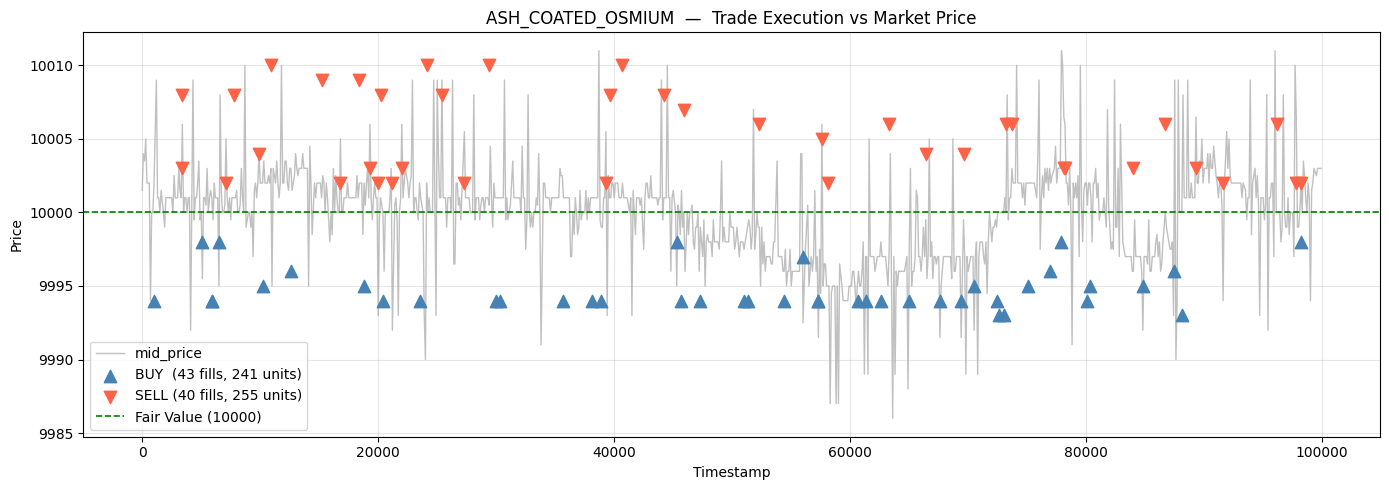

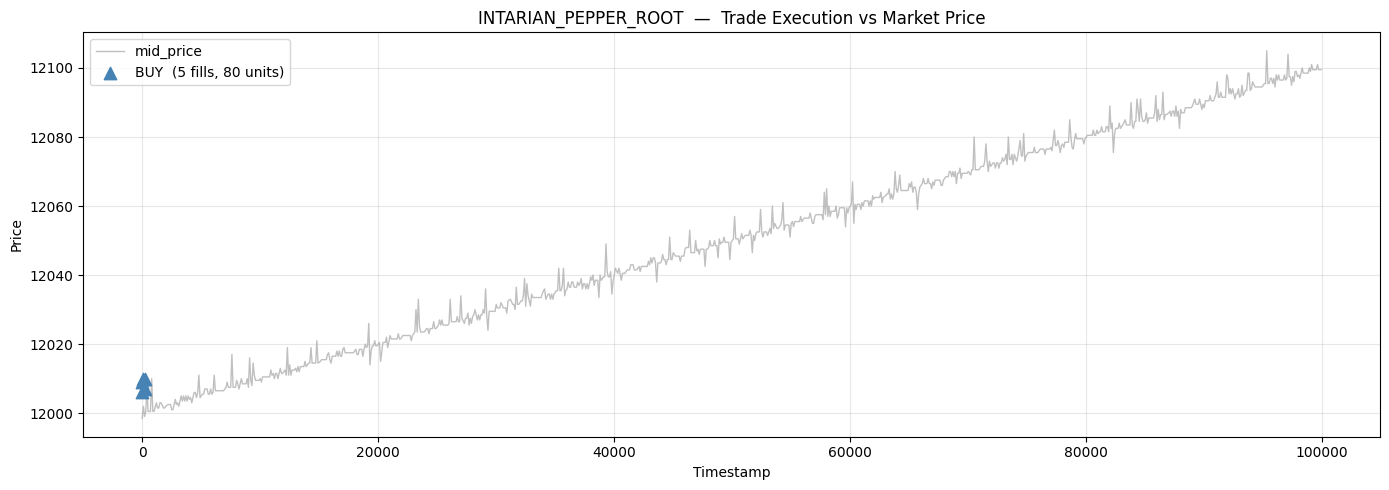

In [79]:
for product in products:
    p = acts[acts["product"] == product].copy()
    t = trades[trades["symbol"] == product].copy()
    buys  = t[t["side"] == "BUY"]
    sells = t[t["side"] == "SELL"]
    p["mid_price"] = p["mid_price"].replace(0, np.nan).ffill()

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(p["global_ts"], p["mid_price"], color="silver", linewidth=1,
            zorder=1, label="mid_price")

    if len(buys):
        ax.scatter(buys["timestamp"], buys["price"],
                   marker="^", color="steelblue", s=80, zorder=5,
                   label=f"BUY  ({len(buys)} fills, {int(buys['quantity'].sum())} units)")
    if len(sells):
        ax.scatter(sells["timestamp"], sells["price"],
                   marker="v", color="tomato", s=80, zorder=5,
                   label=f"SELL ({len(sells)} fills, {int(sells['quantity'].sum())} units)")

    if product in FAIR_VALUES:
        ax.axhline(FAIR_VALUES[product], color="green", linestyle="--",
                   linewidth=1.2, label=f"Fair Value ({FAIR_VALUES[product]})")

    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.set_title(f"{product}  —  Trade Execution vs Market Price")
    ax.legend()
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_03_trades_{product}.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 4. Position Over Time
Reconstructed from `tradeHistory` (cumulative signed quantity).  Red dashed lines mark the ±20 position limits.  
**Flat lines at ±20 = the algo was capacity-constrained** and could not trade even if an edge existed.

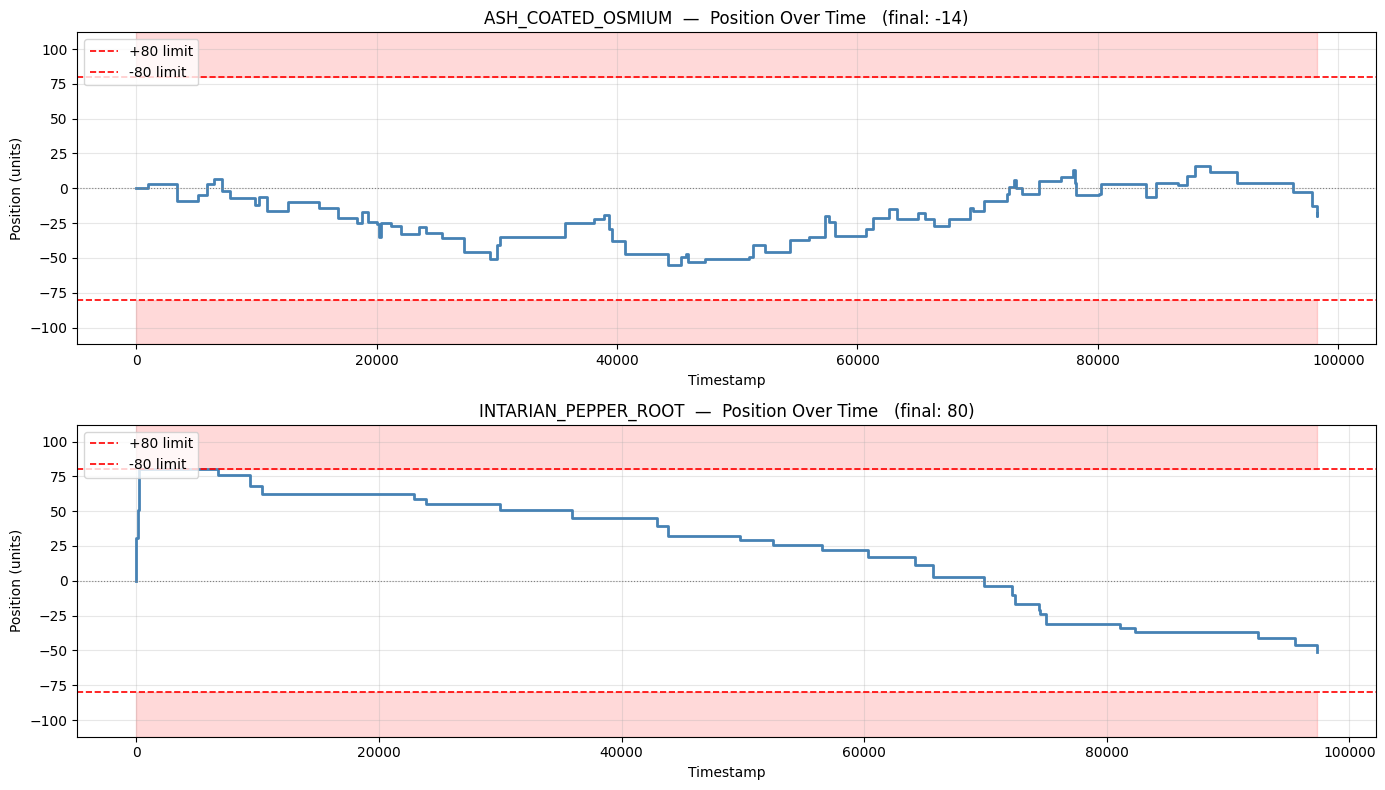

In [80]:
if len(trades) == 0:
    print("No trades — skipping position chart.")
else:
    fig, axes = plt.subplots(len(products), 1,
                             figsize=(14, 4 * len(products)), sharex=False)
    if len(products) == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        t = (trades[trades["symbol"] == product]
             .sort_values("timestamp")
             .copy())
        t["position"] = t["signed_qty"].cumsum()

        timeline = pd.concat([
            pd.DataFrame({"timestamp": [0], "position": [0]}),
            t[["timestamp", "position"]]
        ], ignore_index=True)

        ax.step(timeline["timestamp"], timeline["position"],
                where="post", linewidth=2, color="steelblue")

        # Shade the "forbidden" zones beyond limits
        ylim_pad = POSITION_LIMIT * 0.4
        ax.fill_between(timeline["timestamp"],
                        POSITION_LIMIT, POSITION_LIMIT + ylim_pad,
                        alpha=0.15, color="red")
        ax.fill_between(timeline["timestamp"],
                        -POSITION_LIMIT - ylim_pad, -POSITION_LIMIT,
                        alpha=0.15, color="red")
        ax.axhline( POSITION_LIMIT, color="red", linestyle="--",
                    linewidth=1.2, label=f"+{POSITION_LIMIT} limit")
        ax.axhline(-POSITION_LIMIT, color="red", linestyle="--",
                    linewidth=1.2, label=f"-{POSITION_LIMIT} limit")
        ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")

        # Annotate final position
        fp = final_pos.get(product, "?")
        ax.set_ylabel("Position (units)")
        ax.set_xlabel("Timestamp")
        ax.set_title(f"{product}  —  Position Over Time   (final: {fp})")
        ax.set_ylim(-POSITION_LIMIT - ylim_pad, POSITION_LIMIT + ylim_pad)
        ax.legend(loc="upper left")

    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/results_04_position.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 5. Trade Quality Analysis
**Left**: total volume by side (buy vs sell) with trade count labeled.  
**Right**: scatter of every fill (size ∝ quantity) — shows whether fills are well-distributed across time or bunched at the open/when limits are hit.

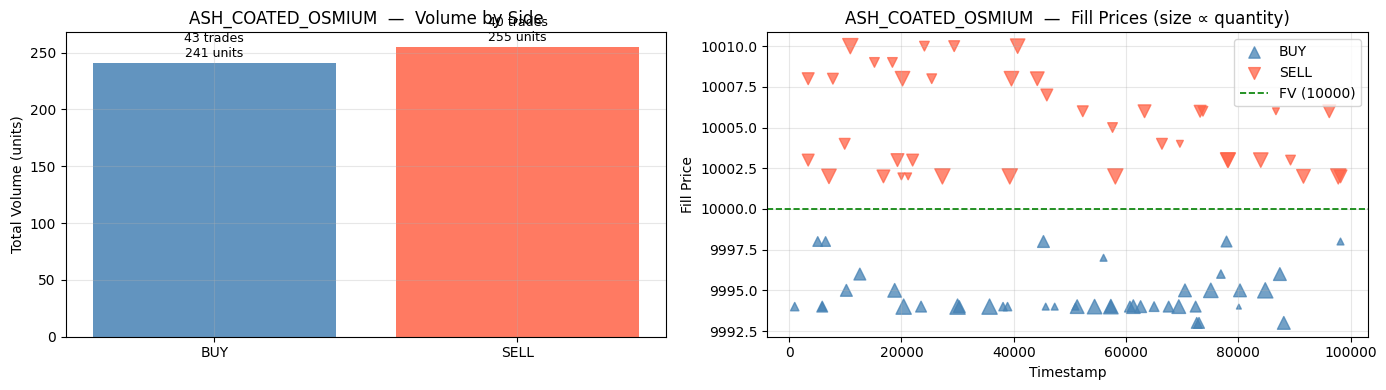

  ASH_COATED_OSMIUM  avg BUY  edge vs FV: +5.26 ticks  (positive = bought below FV — good)
  ASH_COATED_OSMIUM  avg SELL edge vs FV: +5.17 ticks  (positive = sold above FV — good)


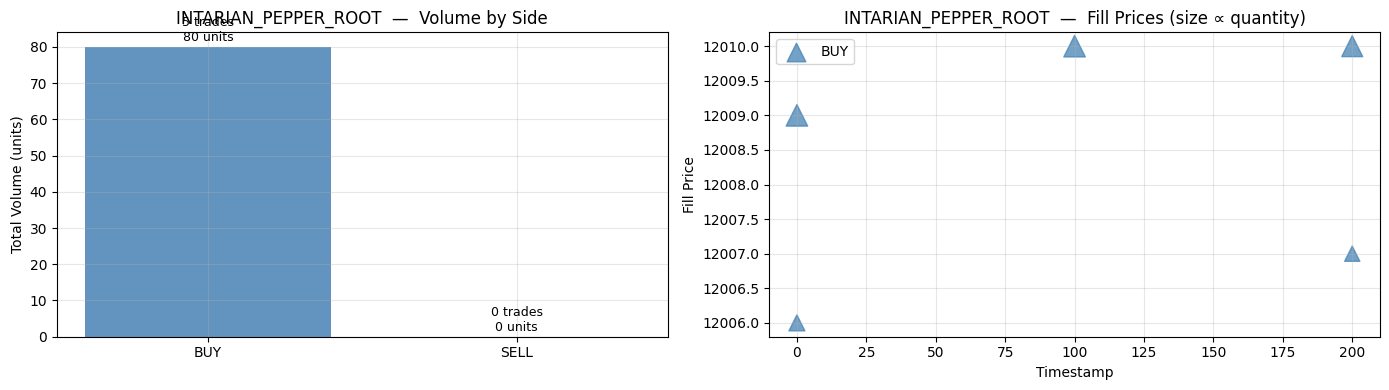

In [81]:
edge_lines = []
if len(trades) == 0:
    print("No trades — skipping trade quality analysis.")
else:
    for product in products:
        t = trades[trades["symbol"] == product].copy()
        buys  = t[t["side"] == "BUY"]
        sells = t[t["side"] == "SELL"]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        # ── Left: volume bar ────────────────────────────────────────────────────
        side_labels = ["BUY", "SELL"]
        volumes     = [int(buys["quantity"].sum()), int(sells["quantity"].sum())]
        counts      = [len(buys), len(sells)]
        bar_colors  = ["steelblue", "tomato"]
        bars = ax1.bar(side_labels, volumes, color=bar_colors, alpha=0.85)
        for bar, vol, cnt in zip(bars, volumes, counts):
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(max(volumes), 1) * 0.02,
                     f"{cnt} trades\n{vol} units",
                     ha="center", fontsize=9)
        ax1.set_ylabel("Total Volume (units)")
        ax1.set_title(f"{product}  —  Volume by Side")

        # ── Right: scatter price vs time ────────────────────────────────────────
        if len(buys):
            ax2.scatter(buys["timestamp"], buys["price"],
                        marker="^", color="steelblue",
                        s=buys["quantity"] * 12, alpha=0.75, label="BUY")
        if len(sells):
            ax2.scatter(sells["timestamp"], sells["price"],
                        marker="v", color="tomato",
                        s=sells["quantity"] * 12, alpha=0.75, label="SELL")
        if product in FAIR_VALUES:
            ax2.axhline(FAIR_VALUES[product], color="green", linestyle="--",
                        linewidth=1.2, label=f"FV ({FAIR_VALUES[product]})")
        ax2.set_xlabel("Timestamp")
        ax2.set_ylabel("Fill Price")
        ax2.set_title(f"{product}  —  Fill Prices (size ∝ quantity)")
        ax2.legend()

        plt.tight_layout()
        fig.savefig(f"{OUTPUT_DIR}/results_05_quality_{product}.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Edge stats ──────────────────────────────────────────────────────────
        if product in FAIR_VALUES:
            fv = FAIR_VALUES[product]
            if len(buys):
                avg_buy_edge  = fv - buys["price"].mean()
                line = (f"  {product}  avg BUY  edge vs FV: {avg_buy_edge:+.2f} ticks  "
                        f"(positive = bought below FV — good)")
                print(line)
                edge_lines.append(line)
            if len(sells):
                avg_sell_edge = sells["price"].mean() - fv
                line = (f"  {product}  avg SELL edge vs FV: {avg_sell_edge:+.2f} ticks  "
                        f"(positive = sold above FV — good)")
                print(line)
                edge_lines.append(line)

with open(f"{OUTPUT_DIR}/results_05_edge_stats.txt", "w") as f:
    f.write("\n".join(edge_lines) + "\n")

---
## 6. Per-Product PnL Breakdown & Summary Table
Uses the final `profit_and_loss` value from `activitiesLog` for each product.  The table shows key stats to compare products head-to-head.

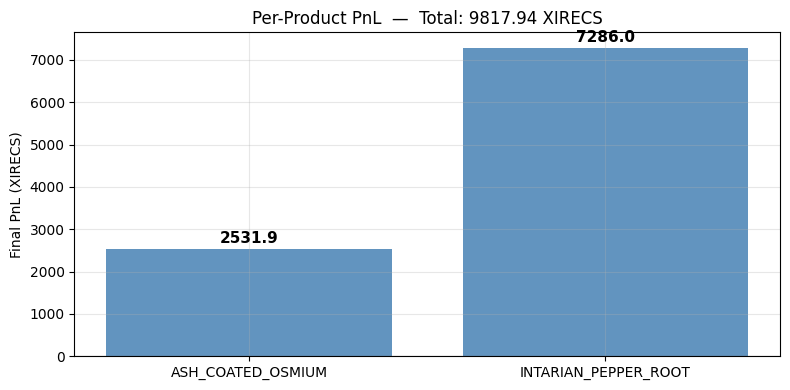

,trades,buy_volume,sell_volume,avg_buy_px,avg_sell_px,final_position,final_pnl
product,,,,,,,
ASH_COATED_OSMIUM,84,241,255,9994.74,10005.17,-14,2531.9375
INTARIAN_PEPPER_ROOT,31,80,0,12008.40,NaN,80,7286.0000


In [82]:
# ── Per-product final PnL ───────────────────────────────────────────────────
product_pnl = {
    product: acts[acts["product"] == product]["profit_and_loss"].iloc[-1]
    for product in products
}

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["steelblue" if v >= 0 else "tomato" for v in product_pnl.values()]
bars = ax.bar(list(product_pnl.keys()), list(product_pnl.values()),
              color=bar_colors, alpha=0.85)
ax.axhline(0, color="grey", linewidth=0.8)
for bar, val in zip(bars, product_pnl.values()):
    y_off = max(product_pnl.values()) * 0.02 if val >= 0 else -max(product_pnl.values()) * 0.06
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_off,
            f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Final PnL (XIRECS)")
ax.set_title(f"Per-Product PnL  —  Total: {sum(product_pnl.values()):.2f} XIRECS")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/results_06_pnl_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
rows = []
for product in products:
    t = trades[trades["symbol"] == product]
    buys  = t[t["side"] == "BUY"]
    sells = t[t["side"] == "SELL"]
    rows.append({
        "product":        product,
        "trades":         len(t),
        "buy_volume":     int(buys["quantity"].sum()),
        "sell_volume":    int(sells["quantity"].sum()),
        "avg_buy_px":     round(buys["price"].mean(),  2) if len(buys)  else None,
        "avg_sell_px":    round(sells["price"].mean(), 2) if len(sells) else None,
        "final_position": final_pos.get(product, None),
        "final_pnl":      round(product_pnl[product], 4),
    })

summary = pd.DataFrame(rows).set_index("product")
display(summary)
summary.to_csv(f"{OUTPUT_DIR}/results_06_summary_table.csv")

---
## 7. Position Limit Constraint Analysis
Answers: **how much profit did we leave on the table because we were maxed out?**  
For each timestep where the algo was at the position limit, we check whether there was a profitable order on the book we couldn't hit.

*Only runs for products with a known static fair value (dynamic FV products are skipped).*

=== ASH_COATED_OSMIUM ===
  Time at max LONG  (+80): 0.0%  of ticks
  Time at max SHORT (-80): 0.0%  of ticks
  Missed BUY  opportunities : 0 ticks  (~0.0 XIRECS edge left on table)
  Missed SELL opportunities : 0 ticks  (~0.0 XIRECS edge left on table)



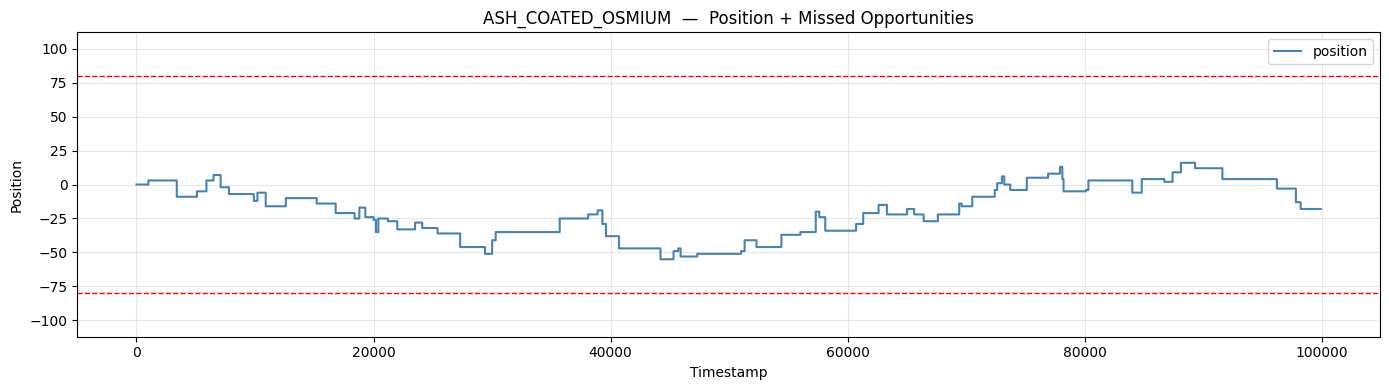

INTARIAN_PEPPER_ROOT: dynamic fair value — skipping constraint analysis



In [83]:
constraint_lines = []
if len(trades) == 0:
    print("No trades — skipping constraint analysis.")
else:
    for product in products:
        fv = FAIR_VALUES.get(product)
        if fv is None:
            print(f"{product}: dynamic fair value — skipping constraint analysis\n")
            continue

        p = acts[acts["product"] == product].copy().reset_index(drop=True)
        t = (trades[trades["symbol"] == product]
             .sort_values("timestamp")
             .copy())
        t["position"] = t["signed_qty"].cumsum()

        # Map each activities timestamp → running position at that tick
        pos_at_ts = dict(zip(t["timestamp"], t["position"]))
        current_pos = 0
        positions_list = []
        for ts in p["timestamp"]:
            if ts in pos_at_ts:
                current_pos = pos_at_ts[ts]
            positions_list.append(current_pos)
        p["position"] = positions_list

        # Missed opportunities
        p["missed_buy"]  = (p["position"] >=  POSITION_LIMIT) & (p["ask_price_1"] < fv)
        p["missed_sell"] = (p["position"] <= -POSITION_LIMIT) & (p["bid_price_1"] > fv)

        pct_max_long     = (p["position"] >=  POSITION_LIMIT).mean() * 100
        pct_max_short    = (p["position"] <= -POSITION_LIMIT).mean() * 100
        missed_buy_ticks  = int(p["missed_buy"].sum())
        missed_sell_ticks = int(p["missed_sell"].sum())

        missed_sell_df = p[p["missed_sell"] & p["bid_price_1"].notna()].copy()
        missed_buy_df  = p[p["missed_buy"]  & p["ask_price_1"].notna()].copy()

        total_sell_edge = (missed_sell_df["bid_price_1"] - fv).sum() if len(missed_sell_df) else 0
        total_buy_edge  = (fv - missed_buy_df["ask_price_1"]).sum()  if len(missed_buy_df)  else 0

        lines_out = [f"=== {product} ==="]
        lines_out.append(f"  Time at max LONG  (+{POSITION_LIMIT}): {pct_max_long:.1f}%  of ticks")
        lines_out.append(f"  Time at max SHORT (-{POSITION_LIMIT}): {pct_max_short:.1f}%  of ticks")
        lines_out.append(f"  Missed BUY  opportunities : {missed_buy_ticks} ticks  "
                         f"(~{total_buy_edge:.1f} XIRECS edge left on table)")
        lines_out.append(f"  Missed SELL opportunities : {missed_sell_ticks} ticks  "
                         f"(~{total_sell_edge:.1f} XIRECS edge left on table)")
        lines_out.append("")
        for l in lines_out:
            print(l)
        constraint_lines.extend(lines_out)

        # ── Chart: position vs time with missed-opp regions highlighted ─────────
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.step(p["timestamp"], p["position"], where="post",
                linewidth=1.5, color="steelblue", label="position")
        ax.axhline( POSITION_LIMIT, color="red", linestyle="--", linewidth=1)
        ax.axhline(-POSITION_LIMIT, color="red", linestyle="--", linewidth=1)

        for missed, color, label in [
            (p["missed_sell"], "red",  "missed SELL"),
            (p["missed_buy"],  "blue", "missed BUY"),
        ]:
            missed_ts = p[missed]["timestamp"]
            if len(missed_ts):
                ax.scatter(missed_ts, [POSITION_LIMIT if color == "red" else -POSITION_LIMIT] * len(missed_ts),
                           color=color, s=15, alpha=0.5, zorder=4, label=label)

        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Position")
        ax.set_title(f"{product}  —  Position + Missed Opportunities")
        ax.set_ylim(-POSITION_LIMIT * 1.4, POSITION_LIMIT * 1.4)
        ax.legend()
        plt.tight_layout()
        fig.savefig(f"{OUTPUT_DIR}/results_07_missed_opps_{product}.png", dpi=150, bbox_inches="tight")
        plt.show()

with open(f"{OUTPUT_DIR}/results_07_constraint_analysis.txt", "w") as f:
    f.write("\n".join(constraint_lines) + "\n")